In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('The_Oregon-Massachusetts_Mammography_Database_(OMAMA-DB)_GuestbookResponses.csv')
df.columns = df.columns.str.strip()

def normalize_institution(name):
    if pd.isna(name) or name == '':
        return 'Unknown'
    name = str(name).lower().strip()
    if 'boston university' in name or 'bu' in name:
        return 'Boston University'
    elif 'umass' in name or 'university of massachusetts' in name:
        if 'chan' in name or 'medical' in name:
            return 'UMass Chan Medical School'
        return 'University of Massachusetts Boston'
    elif 'harvard' in name:
        return 'Harvard University'
    elif 'national cancer center uzbekistan' in name:
        return 'National Cancer Center Uzbekistan'
    elif 'ut southwestern' in name:
        return 'UT Southwestern Medical School'
    elif 'manipal' in name:
        return 'Manipal School of Information Science'
    return str(name).strip()

df['Institution'] = df['Institution'].apply(normalize_institution)

df = df[~df['Institution'].astype(str).str.lower().str.contains('test', na=False)]
df = df[~df['Email'].astype(str).str.lower().str.contains('test', na=False)]

print("Total downloads:", len(df))
df.head()

Total downloads: 192


,Guestbook,Dataset,Dataset PID,Date,Type,File Name,File Id,File PID,User Name,Email,Institution,Position,Custom Questions
0,OMAMA-DB Guestbook,2D Mammograms + DeepSight Cancer Annotations,doi:10.7910/DVN/KXJCIU,12/11/2025,Download,original_2d.tar,10058154,NaN,Clifford Lindsay,clifford.lindsay@umassmed.edu,UMass Chan Medical School,Asst. Professor,NaN
1,OMAMA-DB Guestbook,2D Mammograms + DeepSight Cancer Annotations,doi:10.7910/DVN/KXJCIU,12/11/2025,Download,original_2d.tar,10058154,NaN,Clifford Lindsay,clifford.lindsay@umassmed.edu,UMass Chan Medical School,Asst. Professor,NaN
2,OMAMA-DB Guestbook,2D Mammograms + DeepSight Cancer Annotations,doi:10.7910/DVN/KXJCIU,12/11/2025,Download,original_2d.tar,10058154,NaN,Clifford Lindsay,clifford.lindsay@umassmed.edu,UMass Chan Medical School,Asst. Professor,NaN
3,OMAMA-DB Guestbook,2D Mammograms + DeepSight Cancer Annotations,doi:10.7910/DVN/KXJCIU,12/11/2025,Download,original_2d.tar,10058154,NaN,Clifford Lindsay,clifford.lindsay@umassmed.edu,UMass Chan Medical School,Asst. Professor,NaN
4,OMAMA-DB Guestbook,2D Mammograms + DeepSight Cancer Annotations,doi:10.7910/DVN/KXJCIU,12/11/2025,Download,original_2d.tar,10058154,NaN,Clifford Lindsay,clifford.lindsay@umassmed.edu,UMass Chan Medical School,Asst. Professor,NaN


dataset_type
2D    152
3D     40
Name: count, dtype: int64


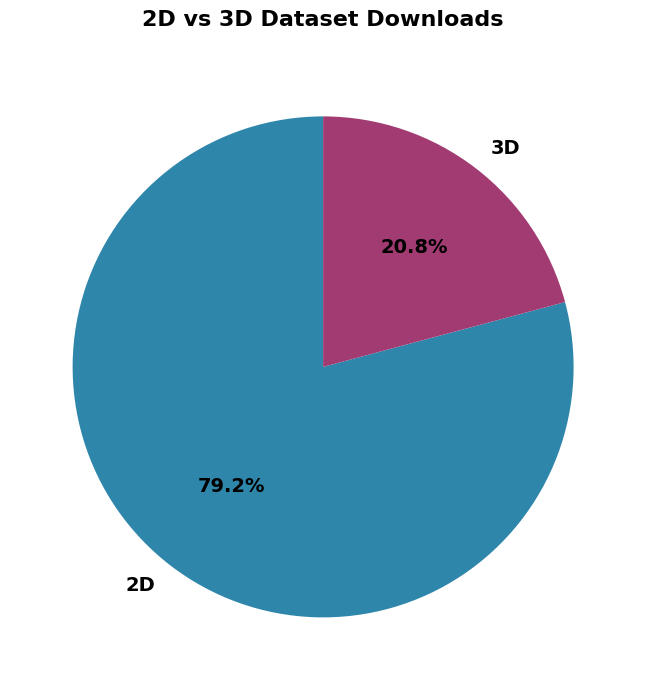

In [2]:
df['dataset_type'] = df['Dataset'].apply(lambda x: '2D' if '2D' in x else '3D')
counts = df['dataset_type'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90, 
       colors=['#2E86AB', '#A23B72'], textprops={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title('2D vs 3D Dataset Downloads', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


File Name
256x256.tar        65
3d.tar             40
1024x1024.tar      32
512x512.tar        28
original_2d.tar    27
Name: count, dtype: int64


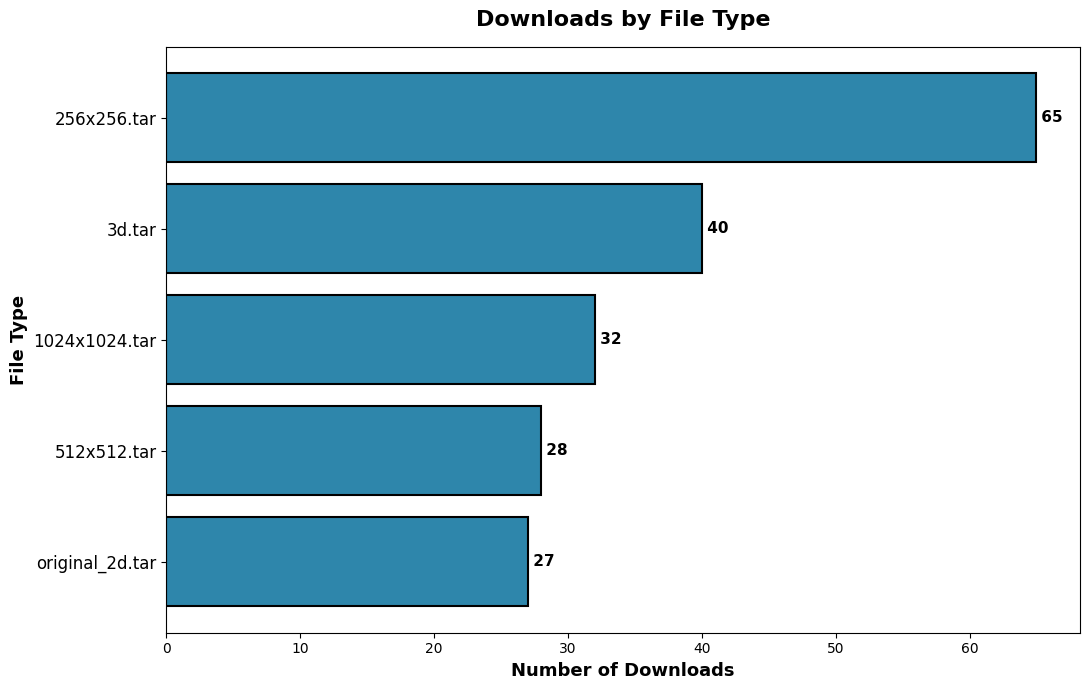

In [3]:
file_counts = df['File Name'].value_counts()
print(file_counts)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(file_counts)), file_counts.values, color='#2E86AB', edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(file_counts)))
ax.set_yticklabels(file_counts.index, fontsize=12)
ax.set_xlabel('Number of Downloads', fontsize=13, fontweight='bold')
ax.set_ylabel('File Type', fontsize=13, fontweight='bold')
ax.set_title('Downloads by File Type', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(False)

for i, v in enumerate(file_counts.values):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
def get_country(institution, email):
    text = (str(institution) + ' ' + str(email)).lower()
    if any(x in text for x in ['india', '.in', 'manipal', 'joseph', 'ssipmt']):
        return 'India'
    elif 'uzbekistan' in text:
        return 'Uzbekistan'
    elif any(x in text for x in ['vienna', 'austria', '.at']):
        return 'Austria'
    elif any(x in text for x in ['sweden', '.se']):
        return 'Sweden'
    elif any(x in text for x in ['turkey', 'sakarya']):
        return 'Turkey'
    elif any(x in text for x in ['canada', '.ca', 'toronto']):
        return 'Canada'
    elif any(x in text for x in ['usa', 'massachusetts', 'boston', 'harvard', 'umass', '.edu', 'rise', 'ebm']):
        return 'USA'
    return 'Other/Unknown'

df['country'] = df.apply(lambda row: get_country(row['Institution'], row['Email']), axis=1)
country_counts = df['country'].value_counts()
print(country_counts)


country
USA              128
Other/Unknown     31
India             15
Uzbekistan        13
Turkey             2
Sweden             1
Austria            1
Canada             1
Name: count, dtype: int64


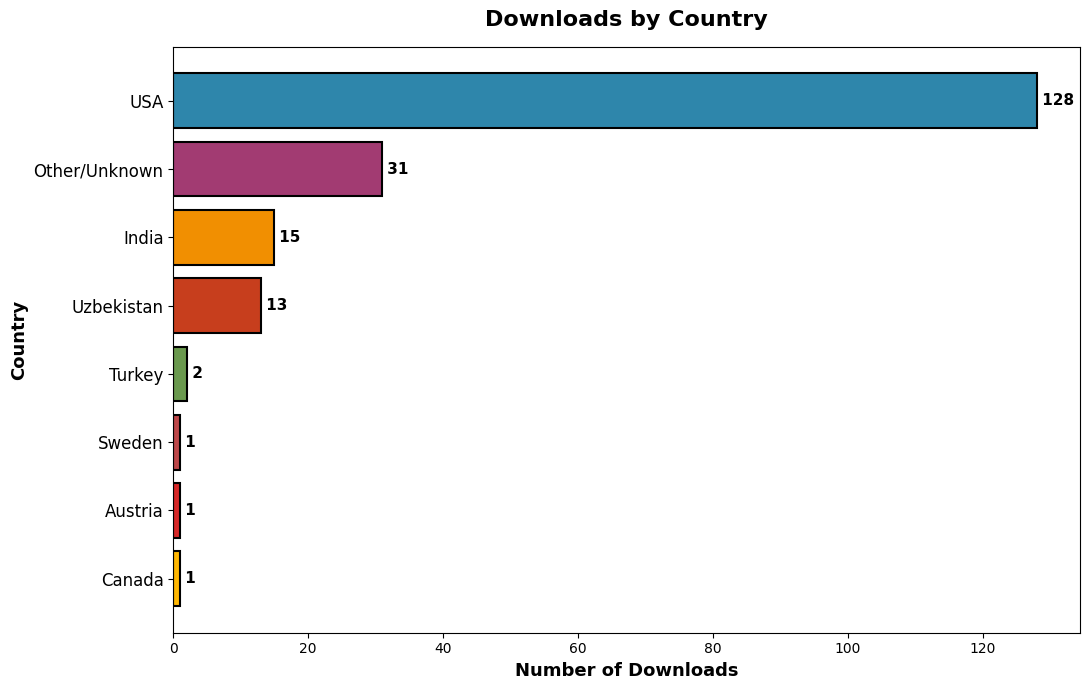

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#D62828', '#FFB703']
ax.barh(range(len(country_counts)), country_counts.values, 
        color=colors[:len(country_counts)], edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(country_counts)))
ax.set_yticklabels(country_counts.index, fontsize=12)
ax.set_xlabel('Number of Downloads', fontsize=13, fontweight='bold')
ax.set_ylabel('Country', fontsize=13, fontweight='bold')
ax.set_title('Downloads by Country', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(False)

for i, v in enumerate(country_counts.values):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
import folium
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time

coords = {'USA': [39.8283, -98.5795], 'India': [20.5937, 78.9629], 'Austria': [47.5162, 14.5501],
          'Uzbekistan': [41.3775, 64.5853], 'Sweden': [60.1282, 18.6435], 'Turkey': [38.9637, 35.2433],
          'Canada': [56.1304, -106.3468]}
colors = {'USA': '#2E86AB', 'India': '#A23B72', 'Austria': '#F18F01', 'Uzbekistan': '#C73E1D',
          'Sweden': '#6A994E', 'Turkey': '#BC4749', 'Canada': '#D62828'}

m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron', width=1200, height=600)
for country, count in country_counts.items():
    if country in coords and country != 'Other/Unknown':
        radius = max(10, min(60, count * 1.5))
        color = colors.get(country, '#2E86AB')
        folium.CircleMarker(location=coords[country], radius=radius,
                           popup=f'<b>{country}</b><br>Downloads: {count}',
                           tooltip=f'{country}: {count} downloads', color='white', fill=True,
                           fillColor=color, fillOpacity=0.7, weight=3).add_to(m)
        folium.Marker(location=coords[country],
                     icon=folium.DivIcon(html=f'<div style="font-size: 12pt; font-weight: bold; color: {color};">{count}</div>',
                                       icon_size=(30, 30), icon_anchor=(15, 15))).add_to(m)

m.save('downloads_map.html')
print("Map saved to downloads_map.html")

try:
    opts = Options()
    opts.add_argument('--headless')
    opts.add_argument('--no-sandbox')
    opts.add_argument('--disable-dev-shm-usage')
    opts.add_argument('--window-size=1200,600')
    driver = webdriver.Chrome(options=opts)
    driver.get('file://' + os.path.abspath('downloads_map.html'))
    time.sleep(2)
    driver.save_screenshot('downloads_map.png')
    driver.quit()
    print("Map saved as PNG: downloads_map.png")
except:
    print("Could not save PNG. HTML file saved instead.")

m


Map saved to downloads_map.html
Map saved as PNG: downloads_map.png


Institution
Boston University                        67
University of Massachusetts Boston       30
Unknown                                  22
National Cancer Center Uzbekistan        13
rise                                      9
Harvard University                        7
UMass Chan Medical School                 7
Manipal School of Information Science     6
UT Southwestern Medical School            5
ebm                                       4
Name: count, dtype: int64


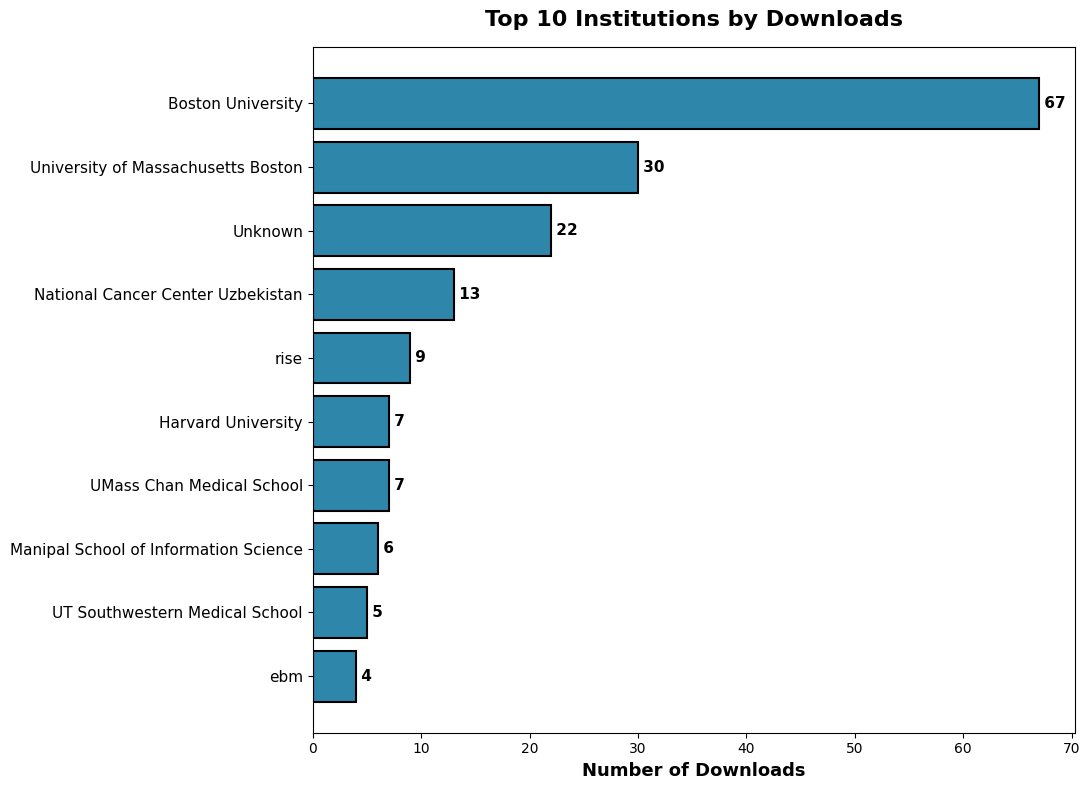

In [7]:
top_inst = df['Institution'].value_counts().head(10)
print(top_inst)

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(range(len(top_inst)), top_inst.values, color='#2E86AB', edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(top_inst)))
ax.set_yticklabels(top_inst.index, fontsize=11)
ax.set_xlabel('Number of Downloads', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Institutions by Downloads', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(False)

for i, v in enumerate(top_inst.values):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


Position
Unknown                  78
Student                  27
it                       24
Researcher               15
Professor                 9
research computing        9
Post Doctorate Fellow     6
rcs                       4
data scientist            4
staff                     3
Name: count, dtype: int64


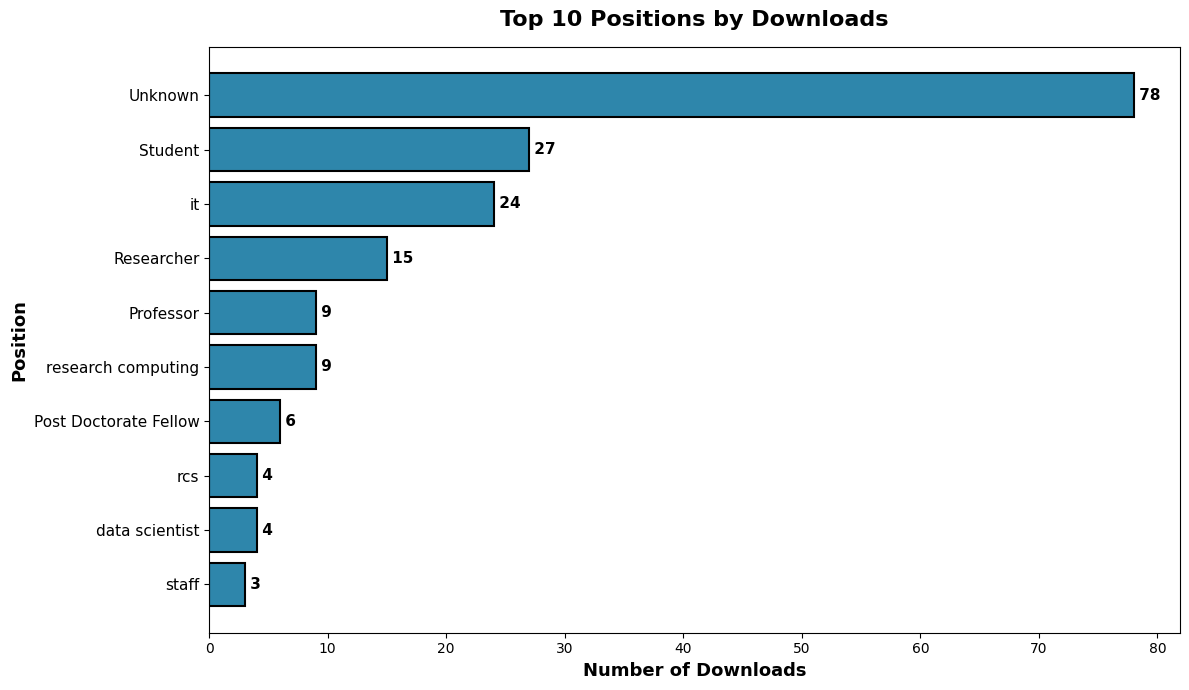

In [8]:
def normalize_position(pos):
    if pd.isna(pos) or pos == '':
        return 'Unknown'
    pos = str(pos).lower().strip()
    if 'student' in pos:
        return 'Student'
    elif 'professor' in pos or 'prof' in pos:
        return 'Professor'
    elif 'researcher' in pos:
        return 'Researcher'
    elif 'phd' in pos:
        return 'PhD Student'
    elif 'post doc' in pos or 'postdoctor' in pos:
        return 'Post Doctorate Fellow'
    return str(pos).strip()

df['Position'] = df['Position'].apply(normalize_position)
pos_counts = df['Position'].value_counts().head(10)
print(pos_counts)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(pos_counts)), pos_counts.values, color='#2E86AB', edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(pos_counts)))
ax.set_yticklabels(pos_counts.index, fontsize=11)
ax.set_xlabel('Number of Downloads', fontsize=13, fontweight='bold')
ax.set_ylabel('Position', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Positions by Downloads', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(False)

for i, v in enumerate(pos_counts.values):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
